# 同じ実励振で比較するCLN・境界応答の補足・POD・Foster

**CLNも実際の励振から場のモードを生成します。PODとの違いは励振の有無ではなく、基底を生成する手順と事前に使う周波数情報です。**

以前の説明はこの点を誤って対比していました。CLNの数値実装はすでに同じ実励振を使っていたので、その値は保持します。表面補足を任意の仮想境界ポートで代表させた比較は、本来の表面モード全般を評価する根拠にはしません。このノートは比較設計と説明を組み直し、二つのメッシュで再計算したものです。

今回は実励振で生じた境界応答を観測して補足を選びます。これは境界応答を使うPODであり、空気領域のSteklovモードとは区別します。Codex自己レビュー済み、Claudeの独立レビューは未実施です。

## 励振・行列・状態数をそろえる

切欠き付き線形3D導体のA–φモデルです。Aの接線境界値、φの端面値、スカラーSchur消去、curlの勾配核処理を全方式で共通にします。同じ正定値行列対 $(K,M)$、同じ実励振ベクトル $f$ を使用します。

正規化した磁気反作用は $Z(u)=u f^T(K+uM)^{-1}f$、$u=s\tau$。展開点は物理単位で $s_0=2\pi10^4$、行列では $u_0=s_0\tau$ です。比較内積は $E=K+u_0M$。これは磁気項と重み付き損失項の正定値内積であり、蓄積磁気エネルギーだけではありません。

| 方式 | 同じ励振から基底を作る方法 | 事前に使う情報 |
|---|---|---|
| 単一展開点CLN | 初期場 $(K+u_0M)^{-1}f$、Type1の場の漸化式 | 1実展開点での段別solve |
| 複数展開点CLN基底 | 同じ$f$から各実展開点のCLN基底を生成して統合 | 最大4実展開点、同じ総状態数 |
| CLN2＋境界応答補足 | 同じ$f$の周波数場から、CLN2で残る境界応答を圧縮 | 31周波数の全自由度解と境界観測 |
| CLN2＋全領域の残差POD | 同じ$f$の周波数場から、CLN2で残る全領域の場を圧縮 | 同じ31周波数の全自由度解 |
| 全領域POD | 同じ$f$の周波数場を圧縮 | 同じ31周波数の全自由度解 |

総状態数は4/8/12。CLN2は磁気場2状態（元のType1ではR/L合計4要素）です。混合後も2段の物理的回路を保持できたという意味ではありません。総状態数はそろえていますが、事前計算の費用や周波数情報は同じではありません。

In [1]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
DATA=Path('data')
coarse=json.loads((DATA/'same_excitation_3d_coarse.json').read_text())
fine=json.loads((DATA/'same_excitation_3d_fine.json').read_text())
print('物理自由度:',[d['mesh']['physical_dimension'] for d in [coarse,fine]])
print('同じ右辺を満たす相対残差:',[d['common_source_checks'] for d in [coarse,fine]])
print('全自由度の場: 直接解との相対差',[d['direct_field_reference_difference'] for d in [coarse,fine]])
assert all(d['source_contract']['no_virtual_port_excitation'] for d in [coarse,fine])


物理自由度: [305, 1399]
同じ右辺を満たす相対残差: [{'snapshot_equation_residual': 8.703697571309722e-15, 'CLN_initial_equation_residual': 5.867872521354308e-16}, {'snapshot_equation_residual': 2.2554453330477312e-14, 'CLN_initial_equation_residual': 9.93689739616732e-16}]
全自由度の場: 直接解との相対差 [2.1625387161248364e-15, 5.70085561265969e-15]


## 境界観測から補足を選ぶ

全領域PODと境界応答補足は、同じ実励振の場

$$X_\ell=(K+i\omega_\ell\tau M)^{-1}f$$

を使います。31周波数は1 kHz〜1 MHz。各複素場を共通内積$E$で規格化し、実部・虚部の62列を作ります。CLN2の成分を$E$内積で除いた残差を$W$とします。

境界応答補足では、外形面中心付近の12個の滑らかな磁束密度観測

$$g_j(A)=\int_{\partial\Omega}w_j d_j\cdot\operatorname{curl}A\,dS$$

から観測行列$T=G W$を作り、$T=U\Sigma V^T$の主要方向を選びます。補足する全領域の場は$WV_j$です。観測の単位の差は$E$の双対内積による規格化で処理します。

**$g_j$を新しい励振として周波数solveすることはありません。** NGSolveでは磁束密度を体積側から境界上に評価します。補足は全領域の場の組合せなので、境界付近だけに局在するとは仮定しません。また、境界観測のPODを全領域のエネルギー内積で最適なPODとも呼びません。

## Steklovの表面モードはPODではない

既存の空気領域の表面モードでは、空気をSchur消去した境界演算子

$$S=K_{\Gamma\Gamma}-K_{\Gamma I}K_{II}^{-1}K_{I\Gamma}$$

と境界質量行列$B_\Gamma$から、$Sv_j=\lambda_j B_\Gamma v_j$のSteklovモードを作ります。これは演算子によるモード分解です。実際の励振は縮約した右辺と、各モードの励起係数に入ります。

一方、実励振の応答場・境界応答のスナップショットをSVDで打ち切る方法はPODです。「表面モードを加える＝POD」とは限らず、**実励振に合わせて表面応答を圧縮する今回の追加方法はPOD**、という整理です。[PODの事前計算と基底生成](https://pmc.ncbi.nlm.nih.gov/articles/PMC3672853/)を参照してください。

この3D内部導体モデルには外部空気がないため、上記の3D Steklov演算子を検証したとは扱いません。[以前の2D表面モード実験](07_surface_hybrid_foster.ipynb)と区別します。旧3Dの仮想境界ポートの不振から、Steklov表面モードやCLN＋表面モード全般の有効性を否定する結論は撤回します。

In [2]:
labels=['ordinary CLN 4','multipoint CLN 4','bulk2 + boundary-response POD 4',
        'bulk2 + field-residual POD 4','field POD 4']
print('細メッシュ、4状態: 1kHz〜1MHz、%単位')
print(f"{'方式':40s} {'端子最大':>10s} {'場最大':>10s} {'DC傾き誤差':>12s}")
for label in labels:
    v=fine['runs'][label]
    print(f"{label:40s} {100*v['high_band_max']:10.5f} {100*v['field_high_band_max']:10.5f} {100*v['DC_slope_error']:12.5f}")


細メッシュ、4状態: 1kHz〜1MHz、%単位
方式                                             端子最大        場最大       DC傾き誤差
ordinary CLN 4                              1.06574   30.10261      0.00001
multipoint CLN 4                            0.07360    6.50676      0.00005
bulk2 + boundary-response POD 4             0.05016    6.76828      0.00327
bulk2 + field-residual POD 4                0.04938    5.77465      0.00406
field POD 4                                 0.03038    5.34979      0.01539


## 同じ基底の結合行列とFoster端子等価回路

表面応答から補足した基底は、CLNの段別漸化式・物理的な直交関係を満たすとは限りません。そこで、$K_q=Q^TKQ$、$M_q=Q^TMQ$の結合を残して評価します。元のCLNのバルクと補足が独立な回路枝になるとは仮定しません。

今回の線形・正定値・同一入出力モデルでは、結合行列の一般化固有モードから

$$Z_q(u)=\sum_j r_j\frac{u}{u+p_j},\qquad p_j>0,\quad r_j\geq0$$

というFoster端子等価回路を作れます。正規化変数$u$で各枝は$R_j=r_j$、$L_j=r_j/p_j$の並列RL、枝同士は直列です。これは端子等価性であり、各枝と元のCLN段・表面場の対応を保証しません。物理単位への換算には時間と端子の規格化を戻します。

通常CLN、複数展開点基底、POD、補足を含むモデルのいずれも、同じ基底の結合行列とFoster表現が数値精度で一致しました。**Foster化そのものでは精度は変わりません。** 差は基底・打切り・利用する帯域情報から生じます。補足込みの物理的Cauerはしご回路や、非線形系の固定Foster回路を導出したという結果ではありません。

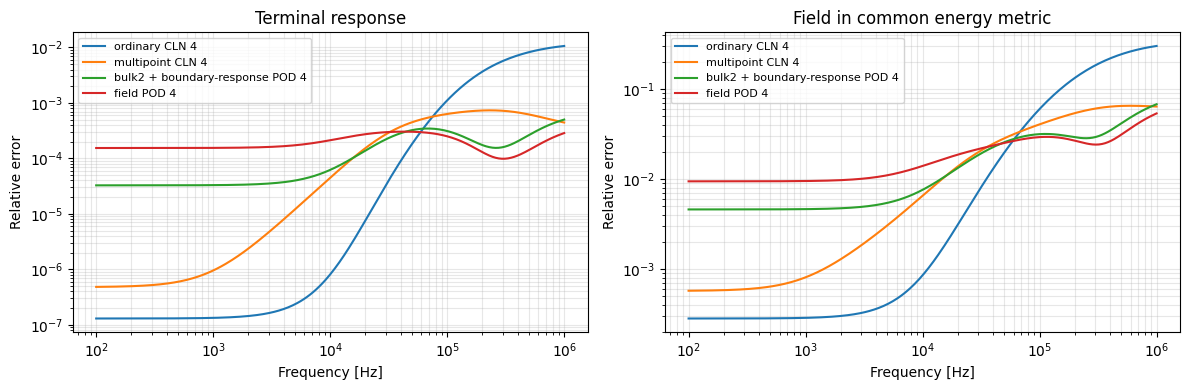

全モデル: 結合行列対Foster最大相対差 1.8387902758841116e-14


In [3]:
fig,axes=plt.subplots(1,2,figsize=(12,4))
for label in ['ordinary CLN 4','multipoint CLN 4','bulk2 + boundary-response POD 4','field POD 4']:
    v=fine['runs'][label]
    axes[0].loglog(fine['frequency_hz'],np.maximum(v['relative_error'],1e-15),label=label)
    axes[1].loglog(fine['frequency_hz'],np.maximum(v['field_energy_relative_error'],1e-15),label=label)
axes[0].set_title('Terminal response');axes[1].set_title('Field in common energy metric')
for ax in axes:
    ax.set_xlabel('Frequency [Hz]');ax.set_ylabel('Relative error');ax.grid(True,which='both',alpha=.3);ax.legend(fontsize=8)
plt.tight_layout();plt.show()
print('全モデル: 結合行列対Foster最大相対差',max(v['coupled_vs_foster'] for d in [coarse,fine] for v in d['runs'].values()))


In [4]:
print('状態数とメッシュの比較: 高帯域端子最大誤差 [%]、粗/細')
for n in [4,8,12]:
    for prefix in ['ordinary CLN','multipoint CLN','bulk2 + boundary-response POD','field POD']:
        label=f'{prefix} {n}'
        print(label,[100*d['runs'][label]['high_band_max'] for d in [coarse,fine]])
print('学習周波数と一致する点を除いた端子最大誤差 [%]')
for label in labels: print(label,100*fine['runs'][label]['holdout_high_band_max'])
a=np.asarray(coarse['reference_real'])+1j*np.asarray(coarse['reference_imag'])
b=np.asarray(fine['reference_real'])+1j*np.asarray(fine['reference_imag'])
print('正規化全自由度応答のメッシュ間最大差 [%]',100*np.max(abs(a/b-1)))


状態数とメッシュの比較: 高帯域端子最大誤差 [%]、粗/細
ordinary CLN 4 [0.35739654520289865, 1.0657377774692518]
multipoint CLN 4 [0.03778101510300146, 0.07359518544216954]
bulk2 + boundary-response POD 4 [0.022168344945423746, 0.05015960795058405]
field POD 4 [0.015478055365612697, 0.030376216749583025]
ordinary CLN 8 [0.005226163591017404, 0.041749239980994494]
multipoint CLN 8 [2.300393432268865e-05, 0.00032144092919741344]
bulk2 + boundary-response POD 8 [3.5260317651666564e-06, 5.251152747362689e-05]
field POD 8 [3.833178059140462e-06, 5.85125739113895e-05]
ordinary CLN 12 [0.00010423304081937426, 0.0027959091114776544]
multipoint CLN 12 [2.0321804318422646e-08, 1.1092551121998717e-06]
bulk2 + boundary-response POD 12 [1.565615712150522e-09, 3.5437222121086516e-08]
field POD 12 [5.38651535253872e-10, 3.613645798590639e-08]
学習周波数と一致する点を除いた端子最大誤差 [%]
ordinary CLN 4 1.058033638621567
multipoint CLN 4 0.07359518544216954
bulk2 + boundary-response POD 4 0.04918776804529601
bulk2 + field-residual POD 4 0.049375

## この比較から言えること

- **CLNもPODも同じ実励振を使用します。** 単一展開点と、多数の周波数の全系解から作るPODの差を、励振の有無の差にはしません。
- 複数展開点CLN基底で帯域を意識すると、細メッシュ4状態の端子最大誤差は約0.0736%。CLN2＋実励振の境界応答補足は約0.0502%。今回の端子精度は近い水準です。
- 全領域PODの端子最大誤差は約0.0304%ですが、場の最大誤差は約5.35%残ります。境界応答補足は端子約0.0502%、場約6.77%、複数展開点CLNは端子約0.0736%、場約6.51%。端子誤差だけで場の再現性を決めません。
- PODには31周波数の全系応答が必要です。この実験では全一般化固有系で生成しました。CLNと事前計算コストが同じという比較ではなく、産業規模の計算時間の優劣も決めません。
- メッシュ間の全自由度応答には約3.46%の差があります。どの縮約も、このメッシュにない表皮層の情報を追加してはいません。

したがって「CLNかFosterか」という端子回路の形式と、「どの場・境界情報から基底を作るか」を分けて評価します。Foster端子等価化の確認はできましたが、混合した場を物理的な段別回路として取り出す課題は残っています。

## 再計算

[同じ実励振で比較するコード](../validation/surface_hybrid/compare_same_excitation_3d.py)と[保存結果の検証](../validation/surface_hybrid/validate_same_excitation_3d.py)を使います。

```text
python validation/surface_hybrid/compare_same_excitation_3d.py --maxh .004 --output coarse.json
python validation/surface_hybrid/compare_same_excitation_3d.py --maxh .003 --output fine.json
python validation/surface_hybrid/validate_same_excitation_3d.py
```

FEM再計算にはNGSolve・numpy・scipy、図表にはmatplotlib、保存結果の点検にはnumpyが必要です。旧データと照合し、単一・複数展開点CLNの値を意図せず変更していないことも検査します。旧仮想境界ポートのコード・記録は再現履歴として残していますが、このノートの主比較・結論には使用しません。
